In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
#Step 1 - load the metadata for tumor purity column
DATA = Path("../../R_scripts_dea_gsea/results/files_for_python")

patient_metadata = pd.read_csv(DATA/"tcga_meta_01.tsv", sep="\t", index_col=0)

print("Metadata shape: ", patient_metadata.shape)

Metadata shape:  (304, 937)


In [3]:
#loading cox_input_emt_only.tsv

DATA2 = Path("../results/cox")

cox = pd.read_csv(DATA2/"cox_input_emt_only.tsv", sep="\t", index_col=0)

print("Cox input shape: ", cox.shape)

Cox input shape:  (291, 3)


In [4]:
#Step 2 - find columns related to tumour purity
for col in patient_metadata.columns:
  if any(x in col.lower() for x in ["purity", "estimate", "stromal", "immune", "cpe", "score"]):
    print(col)

tcga.cgc_case_performance_status_score_ecog
tcga.cgc_case_performance_status_score_timing
tcga.cgc_case_performance_status_score_karnofsky
tcga.cgc_slide_percent_stromal_cells
tcga.xml_karnofsky_performance_score
tcga.xml_patient_history_immune_system_and_related_disorders_names
tcga.xml_patient_history_immune_system_and_related_disorders_text
tcga.xml_immunohistochemistry_positive_cell_score
tcga.xml_metastatic_breast_carcinoma_immunohistochemistry_er_pos_cell_score
tcga.xml_metastatic_breast_carcinoma_immunohistochemistry_pr_pos_cell_score
tcga.xml_breast_carcinoma_immunohistochemistry_pos_cell_score
tcga.xml_primary_pathology_karnofsky_performance_score
tcga.xml_fibrosis_ishak_score
tcga.xml_primary_pathology_fibrosis_ishak_score


In [5]:
#Step 3 - inspecting the tcga.cgc_slide_percent_stromal_cells column

print(patient_metadata["tcga.cgc_slide_percent_stromal_cells"].describe())

count    304.000000
mean      13.667763
std       11.215772
min        0.000000
25%        5.000000
50%       14.000000
75%       20.000000
max       65.000000
Name: tcga.cgc_slide_percent_stromal_cells, dtype: float64


In [6]:
print(patient_metadata["tcga.cgc_slide_percent_stromal_cells"].head(20))

5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a    30
d9096909-1439-462d-b69c-cad1bf4f420c     5
29c17355-d646-48da-9e54-7b6dd85dd610     0
29bcba51-2580-473d-9cf7-bedbd0dbad1b    15
ad97b334-e034-4d33-a4d5-48c32d5d521c    30
99d84d46-19da-43f1-b639-dce9953f1529    30
6ec25686-4547-459c-9e01-7edf8daece35    13
6bca24e6-440f-42c5-abe5-66c37b713a39    35
dd51c17c-300f-44a4-955a-c9bc85417842    25
78c26a05-2084-494d-83d3-c52c1b800f4c    15
d365a238-4739-4b54-9608-dc548f21c04e     8
d587a993-3c47-4d4c-b744-59169d4f7451    20
ba732ed4-f6ba-404e-ba3c-ca558fad866a    25
b2088466-fa5d-491c-9982-99b33683e66f    20
2b5dd791-7692-4721-9519-7d7d49b52570    20
6752eed9-7990-433f-a206-d5398c396471     0
f941890e-ab33-478f-8c97-1c785dd9428f    15
c1411cda-814d-4e21-8929-c0f77858828f    15
ef357c46-5c3c-4f51-9383-ff7694d07b97     0
aaae0bd9-63fc-4a0e-a27e-447b634bad99     0
Name: tcga.cgc_slide_percent_stromal_cells, dtype: int64


In [7]:
print(patient_metadata["tcga.cgc_slide_percent_stromal_cells"].isna().sum())

0


In [8]:
#Step 4 - converting the stromal percentage to tumor purity estimate

patient_metadata["tumour_purity"] = 100 - patient_metadata["tcga.cgc_slide_percent_stromal_cells"]

In [9]:
print(patient_metadata["tumour_purity"].head(20))


5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a     70
d9096909-1439-462d-b69c-cad1bf4f420c     95
29c17355-d646-48da-9e54-7b6dd85dd610    100
29bcba51-2580-473d-9cf7-bedbd0dbad1b     85
ad97b334-e034-4d33-a4d5-48c32d5d521c     70
99d84d46-19da-43f1-b639-dce9953f1529     70
6ec25686-4547-459c-9e01-7edf8daece35     87
6bca24e6-440f-42c5-abe5-66c37b713a39     65
dd51c17c-300f-44a4-955a-c9bc85417842     75
78c26a05-2084-494d-83d3-c52c1b800f4c     85
d365a238-4739-4b54-9608-dc548f21c04e     92
d587a993-3c47-4d4c-b744-59169d4f7451     80
ba732ed4-f6ba-404e-ba3c-ca558fad866a     75
b2088466-fa5d-491c-9982-99b33683e66f     80
2b5dd791-7692-4721-9519-7d7d49b52570     80
6752eed9-7990-433f-a206-d5398c396471    100
f941890e-ab33-478f-8c97-1c785dd9428f     85
c1411cda-814d-4e21-8929-c0f77858828f     85
ef357c46-5c3c-4f51-9383-ff7694d07b97    100
aaae0bd9-63fc-4a0e-a27e-447b634bad99    100
Name: tumour_purity, dtype: int64


In [10]:
#Step 5 - merging the cox inout with the tumour_purity column

cox = cox.merge(patient_metadata[["tumour_purity"]], left_index=True, right_index=True, how="left")

In [11]:
print(cox.shape)

(291, 4)


In [12]:
print(cox["tumour_purity"].isna().sum())

0


In [13]:
print(cox.columns)

Index(['time_days', 'event', 'EMT', 'tumour_purity'], dtype='object')


In [14]:
#Step 6 - correlation between the EMT score and tumour purity estimate

cox[["EMT", "tumour_purity"]].corr()

,EMT,tumour_purity
EMT,1.000000,-0.072931
tumour_purity,-0.072931,1.000000


In [15]:
#Step 7 - checking tumour_purity column distribution

cox["tumour_purity"].describe()

count    291.000000
mean      86.426117
std       11.259197
min       35.000000
25%       80.000000
50%       87.000000
75%       95.000000
max      100.000000
Name: tumour_purity, dtype: float64

In [16]:
#Step 8 - fitting a cox proportional hazards model
from lifelines import CoxPHFitter

In [17]:
cox["purity_scaled"] = cox["tumour_purity"] / 10

In [18]:
cox.columns

Index(['time_days', 'event', 'EMT', 'tumour_purity', 'purity_scaled'], dtype='object')

In [19]:
cph = CoxPHFitter()

cph.fit(cox[["time_days", "event", "EMT", "purity_scaled"]],
        duration_col="time_days",
        event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 291 total observations, 220 right-censored observations>
             duration col = 'time_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 291
number of events observed = 71
   partial log-likelihood = -341.90
         time fit was run = 2026-05-22 09:33:42 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
EMT            0.28      1.32      0.11            0.05            0.50                1.06                1.65
purity_scaled -0.05      0.95      0.10           -0.25            0.16                0.78                1.17

               cmp to     z    p  -log2(p)
covariate                                 
EMT              0.00  2.44 0.01      6.07
purity_scaled    0.00 -0.46 0.65      0.63
---
Concordance = 0.60
Partial AIC = 687.80
log-likelihood ratio test = 5.95 on 2 df
-log2(p) of ll-ratio test = 4.29

In [20]:
#Step 9 - save the dataframe used for Cox
OUT = Path("../results/cox")
OUT.mkdir(exist_ok=True)

cox.to_csv(OUT/"Supplementary_Table_S2_cox_input.tsv", sep="\t")

In [21]:
cph.summary.to_csv(OUT/"cox_emt_purity_summary.tsv", sep="\t")

In [22]:
with open(OUT / "cox_emt_purity_metadata.txt", "w") as f:
    f.write(f"Model: Cox proportional hazards\n")
    f.write(f"Predictors: EMT (z-scored) and scaled tumour purity (tumour purity % / 10)\n")
    f.write(f"n_samples: {cox.shape[0]}\n")
    f.write(f"n_events: {cox['event'].sum()}\n")
    f.write(f"Baseline estimation: {cph.baseline_estimation_method}\n")



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.8656)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9641)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3787)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2848)'>]]

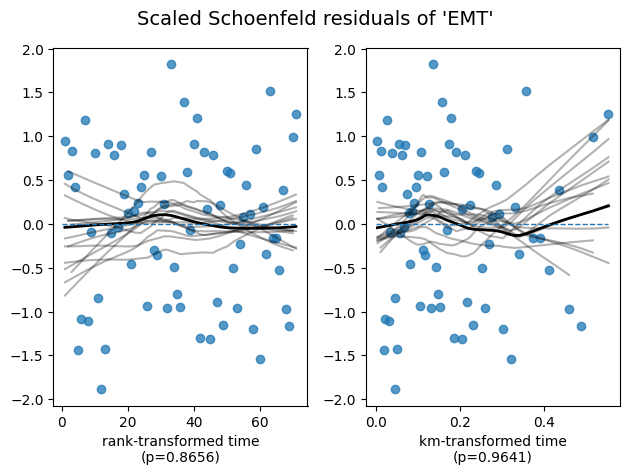

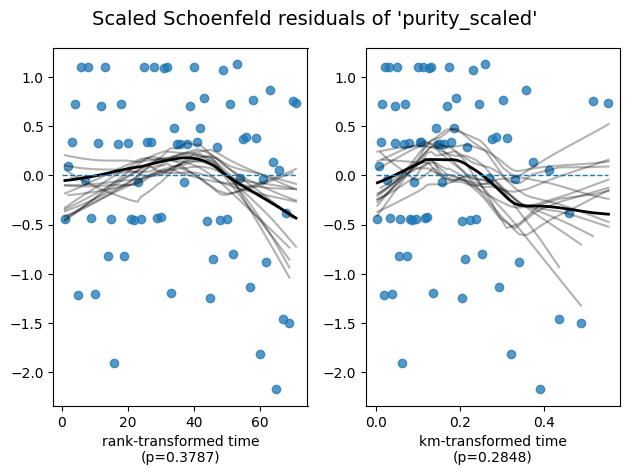

In [23]:
#Step 10 - cox model dianostics
cph.check_assumptions(
    cox[["time_days","event","EMT","purity_scaled"]],
    p_value_threshold=0.05,
    show_plots=True
)

In [24]:
#Step 11 - bootstrap internal validation
cox_boot = cox[["time_days", "event", "EMT", "purity_scaled"]].copy()


In [25]:
cox_boot.columns

Index(['time_days', 'event', 'EMT', 'purity_scaled'], dtype='object')

In [26]:
c_apparent = cph.score(cox_boot, scoring_method="concordance_index")
print("Apparent C-index:", float(c_apparent))

Apparent C-index: 0.5965498554913294


In [27]:
B = 1000
seed = 123
rng = np.random.default_rng(seed)

optimisms = []
boot_train_c = []
boot_test_c = []

n = cox_boot.shape[0]

for b in range(B):
    # draw bootstrap indices with replacement
    idx = rng.integers(0, n, size=n)
    cox_boot_2 = cox_boot.iloc[idx].copy()

     # fit model on bootstrap sample
    cph_b = CoxPHFitter()
    cph_b.fit(cox_boot_2, duration_col="time_days", event_col="event")

    # evaluate discrimination (C-index) on:
    #     bootstrap sample
    #     original full dataset
    c_train = cph_b.score(cox_boot_2, scoring_method="concordance_index")
    c_test  = cph_b.score(cox_boot,      scoring_method="concordance_index")

    boot_train_c.append(float(c_train))
    boot_test_c.append(float(c_test))
    optimisms.append(float(c_train - c_test))

# average optimism and correct the apparent performance
mean_optimism = float(np.mean(optimisms))
c_corrected = float(c_apparent - mean_optimism)

print("\nBootstrap results")
print("Mean optimism:", mean_optimism)
print("Optimism-corrected C-index:", c_corrected)



/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting


Bootstrap results
Mean optimism: 0.013926926308134106
Optimism-corrected C-index: 0.5826229291831954


/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
